# TP Industrie 4.0 — Apprentissage supervisé / Régression

## Projet InnoMoov — Prédiction intelligente du trafic urbain

InnoMoov est positionnée sur la **mobilité urbaine intelligente**, la **gestion de flotte électrique** et l’exploitation des technologies Industrie 4.0 : IoT, intelligence artificielle, données temps réel, supervision et aide à la décision.

Dans ce TP, l’objectif est de construire un modèle de **régression supervisée** capable de prédire le volume de trafic routier à partir de variables temporelles, météorologiques et calendaires.

La finalité métier est claire : permettre à InnoMoov de passer d’une gestion réactive du trafic à une **mobilité prédictive**.

### Objectifs du notebook

1. Définir un besoin industriel concret.
2. Utiliser un dataset cohérent avec ce besoin.
3. Justifier le choix du modèle avec la carte d’orientation Scikit-Learn.
4. Construire un modèle de régression en quelques lignes.
5. Évaluer les performances avec des métriques adaptées.
6. Visualiser les résultats avec une identité graphique personnalisée.
7. Exploiter le modèle sur des scénarios industriels InnoMoov.
8. Conclure sur l’intérêt opérationnel dans le process industriel.

---

## 1. Besoin industriel identifié

InnoMoov conçoit des solutions de mobilité intelligente pour les villes et les opérateurs de flotte électrique.

Un enjeu industriel majeur est la **prévision du trafic urbain**. Une mauvaise anticipation du trafic peut provoquer :

- des retards dans les déplacements ;
- une mauvaise répartition des véhicules disponibles ;
- une hausse de la consommation énergétique ;
- une augmentation des émissions de CO₂ ;
- une dégradation de la qualité de service ;
- une surcharge de certaines zones urbaines.

### Problématique métier

> Comment prédire le volume de trafic urbain afin d’aider InnoMoov à optimiser la gestion de ses flottes électriques, ses itinéraires et ses décisions opérationnelles ?

### Objectif data science

Construire un modèle de régression qui prédit la variable numérique `traffic_volume` à partir de variables explicatives comme l’heure, le jour, la météo, les précipitations et les jours fériés.

---

In [2]:
# ============================================================
# 0. Imports et configuration générale
# ============================================================

import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

# Palette InnoMoov : vert mobilité, orange industriel, bleu électrique, gris technique
INNO_GREEN = "#2A9D8F"
INNO_ORANGE = "#E76F51"
INNO_BLUE = "#264653"
INNO_YELLOW = "#F4A261"
INNO_GREY = "#F7F7F7"
DARK = "#1D1D1D"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["figure.facecolor"] = "#FFFFFF"
plt.rcParams["axes.facecolor"] = INNO_GREY
plt.rcParams["axes.edgecolor"] = DARK
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["font.family"] = "DejaVu Sans"

RANDOM_STATE = 42

print("Environnement initialisé.")

Environnement initialisé.


## 2. Dataset utilisé

Le dataset retenu est **Metro Interstate Traffic Volume**.

Il contient des observations de trafic routier associées à des informations temporelles et météorologiques :

- date et heure d’observation ;
- température ;
- pluie ;
- neige ;
- couverture nuageuse ;
- condition météo principale ;
- jour férié ;
- volume de trafic observé.

La variable cible est :

> **`traffic_volume`** : volume de trafic à prédire.

Ce dataset est cohérent avec le projet InnoMoov car il permet de simuler une brique d’aide à la décision pour la mobilité intelligente : anticipation des congestions, optimisation des itinéraires et meilleure disponibilité des flottes.

In [3]:
# ============================================================
# 1. Chargement du dataset
# ============================================================

DATA_PATHS = [Path("Metro_Interstate_Traffic_Volume.csv")]

csv_path = next((path for path in DATA_PATHS if path.exists()), None)

if csv_path is None:
    raise FileNotFoundError(
        "Dataset introuvable. Placez le fichier 'Metro_Interstate_Traffic_Volume.csv' "
        "dans le même dossier que ce notebook, ou dans un dossier 'data/'."
    )

df = pd.read_csv(csv_path)

print(f"Dataset chargé : {csv_path}")
print(f"Nombre de lignes : {df.shape[0]:,}".replace(",", " "))
print(f"Nombre de colonnes : {df.shape[1]}")

display(df.head())

Dataset chargé : Metro_Interstate_Traffic_Volume.csv
Nombre de lignes : 48 204
Nombre de colonnes : 9


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [4]:
# ============================================================
# 2. Inspection initiale
# ============================================================

print("Informations générales :")
display(df.info())

print("\nValeurs manquantes par colonne :")
display(df.isna().sum().sort_values(ascending=False))

print("\nStatistiques descriptives :")
display(df.describe(include="all").T)

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48204 entries, 0 to 48203
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   holiday              61 non-null     object 
 1   temp                 48204 non-null  float64
 2   rain_1h              48204 non-null  float64
 3   snow_1h              48204 non-null  float64
 4   clouds_all           48204 non-null  int64  
 5   weather_main         48204 non-null  object 
 6   weather_description  48204 non-null  object 
 7   date_time            48204 non-null  object 
 8   traffic_volume       48204 non-null  int64  
dtypes: float64(3), int64(2), object(4)
memory usage: 3.3+ MB


None


Valeurs manquantes par colonne :


holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64


Statistiques descriptives :


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
holiday,61,11,Labor Day,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
temp,48204.0,NaN,NaN,NaN,281.20587,13.338232,0.0,272.16,282.45,291.806,310.07
rain_1h,48204.0,NaN,NaN,NaN,0.334264,44.789133,0.0,0.0,0.0,0.0,9831.3
snow_1h,48204.0,NaN,NaN,NaN,0.000222,0.008168,0.0,0.0,0.0,0.0,0.51
clouds_all,48204.0,NaN,NaN,NaN,49.362231,39.01575,0.0,1.0,64.0,90.0,100.0
weather_main,48204,11,Clouds,15164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weather_description,48204,38,sky is clear,11665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date_time,48204,40575,2013-05-19 10:00:00,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
traffic_volume,48204.0,NaN,NaN,NaN,3259.818355,1986.86067,0.0,1193.0,3380.0,4933.0,7280.0


## 3. Nettoyage et feature engineering

La prédiction du trafic dépend fortement de la temporalité. Pour rendre le modèle plus intelligent, on enrichit le dataset avec des variables métier :

- `hour` : heure de la journée ;
- `dayofweek` : jour de la semaine ;
- `month` et `year` ;
- `is_weekend` : indicateur week-end ;
- `is_rush_hour` : indicateur d’heure de pointe ;
- `period_of_day` : période de la journée ;
- `hour_sin` et `hour_cos` : représentation cyclique de l’heure ;
- `temp_celsius` : température convertie en degrés Celsius.

La représentation cyclique est importante : 23h et 0h sont proches dans la réalité, même si les valeurs numériques 23 et 0 semblent éloignées pour un modèle.

In [5]:
# ============================================================
# 3. Nettoyage et enrichissement des variables
# ============================================================

df_clean = df.copy()

# Harmonisation des noms de colonnes, au cas où le fichier contient des espaces
# ou des majuscules inattendues.
df_clean.columns = [col.strip() for col in df_clean.columns]

# Gestion des jours fériés
if "holiday" in df_clean.columns:
    df_clean["holiday"] = df_clean["holiday"].fillna("None")

# Conversion de la date
if "date_time" not in df_clean.columns:
    raise KeyError("La colonne 'date_time' est absente du dataset.")

df_clean["date_time"] = pd.to_datetime(df_clean["date_time"])
df_clean = df_clean.sort_values("date_time").reset_index(drop=True)

# Variables temporelles
df_clean["hour"] = df_clean["date_time"].dt.hour
df_clean["dayofweek"] = df_clean["date_time"].dt.dayofweek
df_clean["month"] = df_clean["date_time"].dt.month
df_clean["year"] = df_clean["date_time"].dt.year
df_clean["is_weekend"] = df_clean["dayofweek"].isin([5, 6]).astype(int)

# Heures de pointe : matin et fin de journée
df_clean["is_rush_hour"] = df_clean["hour"].isin([7, 8, 9, 16, 17, 18]).astype(int)

# Périodes de la journée
df_clean["period_of_day"] = pd.cut(
    df_clean["hour"],
    bins=[-1, 5, 11, 16, 20, 23],
    labels=["Nuit", "Matin", "Après-midi", "Soir", "Fin de soirée"]
).astype(str)

# Représentation cyclique de l'heure
df_clean["hour_sin"] = np.sin(2 * np.pi * df_clean["hour"] / 24)
df_clean["hour_cos"] = np.cos(2 * np.pi * df_clean["hour"] / 24)

# Température en Celsius, si la colonne temp est en Kelvin
if "temp" in df_clean.columns:
    df_clean["temp_celsius"] = df_clean["temp"] - 273.15
else:
    raise KeyError("La colonne 'temp' est absente du dataset.")

# Suppression de doublons éventuels
duplicates_before = df_clean.duplicated().sum()
df_clean = df_clean.drop_duplicates().reset_index(drop=True)

print(f"Doublons supprimés : {duplicates_before}")
print(f"Shape après préparation : {df_clean.shape}")

display(df_clean.head())

Doublons supprimés : 17
Shape après préparation : (48187, 19)


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume,hour,dayofweek,month,year,is_weekend,is_rush_hour,period_of_day,hour_sin,hour_cos,temp_celsius
0,None,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545,9,1,10,2012,0,1,Matin,7.071068e-01,-0.707107,15.13
1,None,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516,10,1,10,2012,0,0,Matin,5.000000e-01,-0.866025,16.21
2,None,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767,11,1,10,2012,0,0,Matin,2.588190e-01,-0.965926,16.43
3,None,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026,12,1,10,2012,0,0,Après-midi,1.224647e-16,-1.000000,16.98
4,None,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918,13,1,10,2012,0,0,Après-midi,-2.588190e-01,-0.965926,17.99


## 4. Analyse exploratoire des données

L’analyse exploratoire permet de comprendre les comportements du trafic avant de modéliser.

On cherche notamment à répondre à ces questions :

- le trafic varie-t-il selon l’heure ?
- existe-t-il des jours plus chargés que d’autres ?
- la météo influence-t-elle le volume de circulation ?
- observe-t-on des pics ou des périodes creuses ?

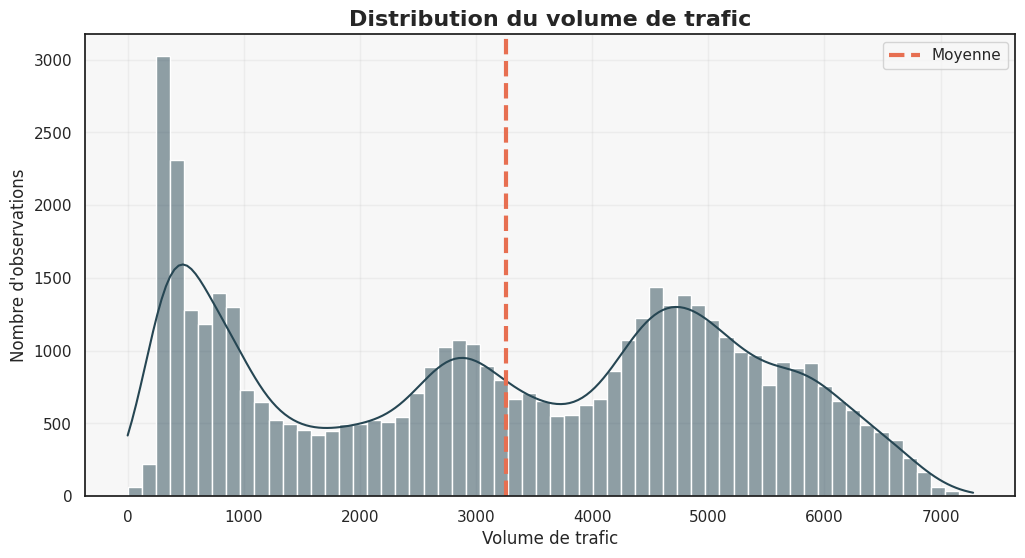

In [6]:
# ============================================================
# 4.1 Distribution de la variable cible
# ============================================================

plt.figure(figsize=(12, 6))
sns.histplot(
    df_clean["traffic_volume"],
    bins=60,
    kde=True,
    color=INNO_BLUE,
    edgecolor="white"
)
plt.axvline(df_clean["traffic_volume"].mean(), color=INNO_ORANGE, linestyle="--", linewidth=3, label="Moyenne")
plt.title("Distribution du volume de trafic")
plt.xlabel("Volume de trafic")
plt.ylabel("Nombre d'observations")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

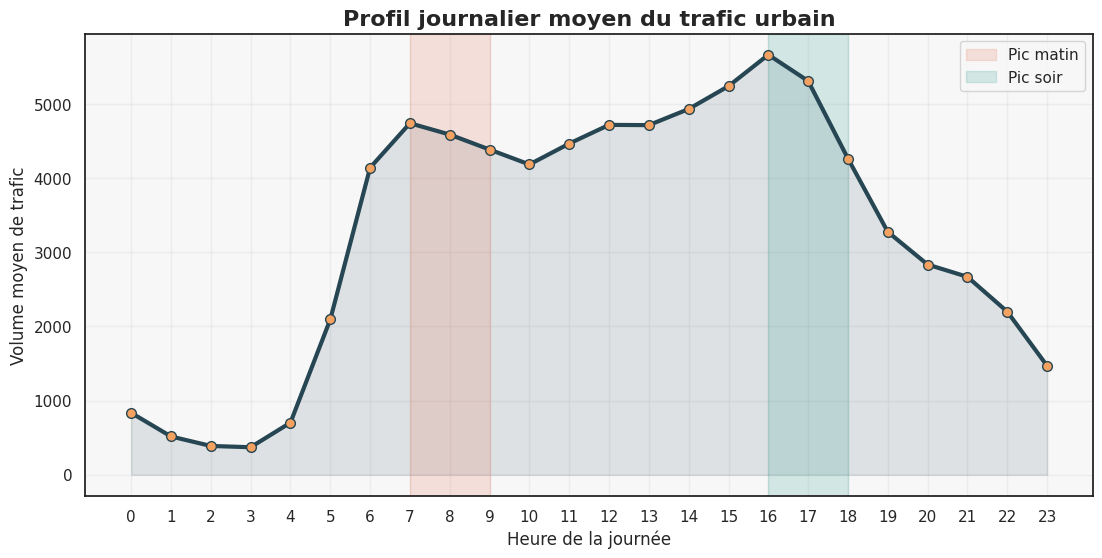

In [7]:
# ============================================================
# 4.2 Profil journalier moyen du trafic
# ============================================================

hourly_traffic = df_clean.groupby("hour", as_index=False)["traffic_volume"].mean()

plt.figure(figsize=(13, 6))
plt.plot(
    hourly_traffic["hour"],
    hourly_traffic["traffic_volume"],
    color=INNO_BLUE,
    linewidth=3,
    marker="o",
    markersize=7,
    markerfacecolor=INNO_YELLOW,
    markeredgecolor=INNO_BLUE
)
plt.fill_between(
    hourly_traffic["hour"],
    hourly_traffic["traffic_volume"],
    color=INNO_BLUE,
    alpha=0.12
)
plt.axvspan(7, 9, color=INNO_ORANGE, alpha=0.18, label="Pic matin")
plt.axvspan(16, 18, color=INNO_GREEN, alpha=0.18, label="Pic soir")
plt.title("Profil journalier moyen du trafic urbain")
plt.xlabel("Heure de la journée")
plt.ylabel("Volume moyen de trafic")
plt.xticks(range(0, 24))
plt.legend()
plt.grid(alpha=0.25)
plt.show()

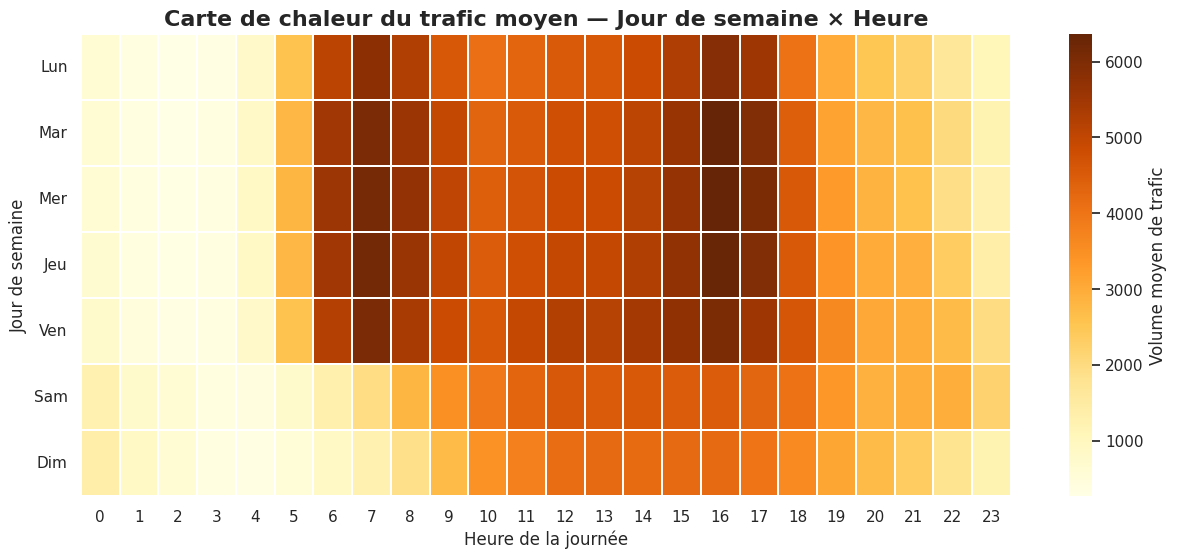

In [8]:
# ============================================================
# 4.3 Heatmap : jour de semaine x heure
# ============================================================

traffic_heatmap = df_clean.pivot_table(
    values="traffic_volume",
    index="dayofweek",
    columns="hour",
    aggfunc="mean"
)

plt.figure(figsize=(15, 6))
sns.heatmap(
    traffic_heatmap,
    cmap="YlOrBr",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Volume moyen de trafic"}
)
plt.title("Carte de chaleur du trafic moyen — Jour de semaine × Heure")
plt.xlabel("Heure de la journée")
plt.ylabel("Jour de semaine")
plt.yticks(
    ticks=np.arange(7) + 0.5,
    labels=["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"],
    rotation=0
)
plt.show()

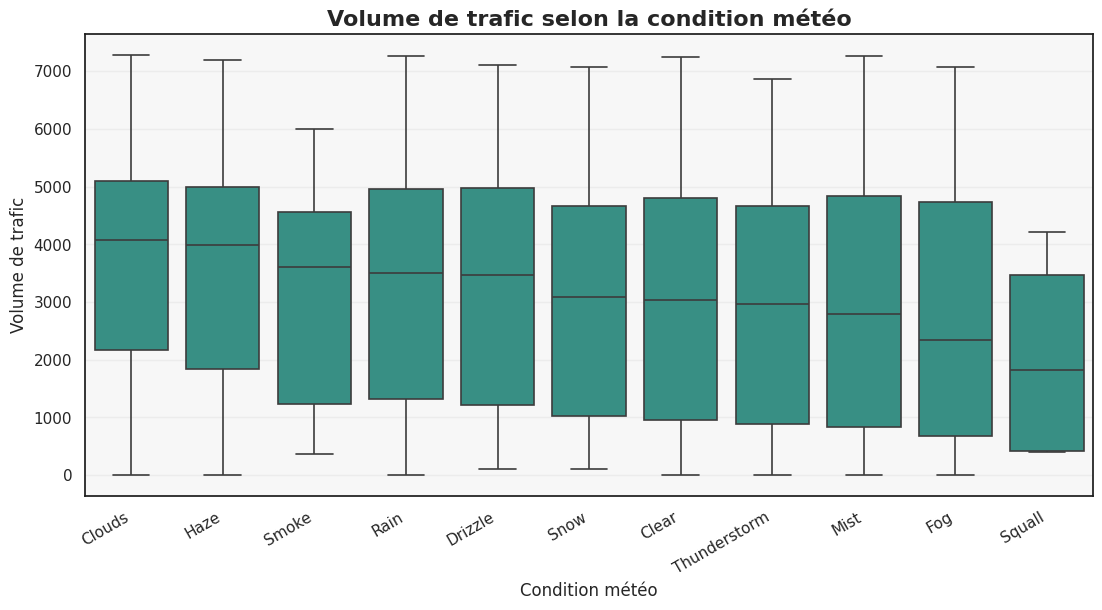

In [9]:
# ============================================================
# 4.4 Impact de la météo sur le trafic
# ============================================================

weather_order = (
    df_clean.groupby("weather_main")["traffic_volume"]
    .median()
    .sort_values(ascending=False)
    .index
)

plt.figure(figsize=(13, 6))
sns.boxplot(
    data=df_clean,
    x="weather_main",
    y="traffic_volume",
    order=weather_order,
    color=INNO_GREEN,
    linewidth=1.2
)
plt.title("Volume de trafic selon la condition météo")
plt.xlabel("Condition météo")
plt.ylabel("Volume de trafic")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.show()

## 5. Choix de l’algorithme avec la carte Scikit-Learn

La carte d’orientation Scikit-Learn conduit le raisonnement suivant :

- la variable cible `traffic_volume` est numérique ;
- le problème est supervisé ;
- il s’agit donc d’un problème de **régression** ;
- le dataset contient un volume de données raisonnable ;
- les relations entre heure, météo, calendrier et trafic sont non linéaires.

### Stratégie retenue

Pour avoir une démarche professionnelle, on ne teste pas uniquement un modèle avancé. On compare trois niveaux :

1. **DummyRegressor** : baseline naïve, qui sert de point de comparaison minimal ;
2. **Ridge Regression** : modèle linéaire régularisé, interprétable ;
3. **Random Forest Regressor** : modèle non linéaire adapté aux interactions complexes.

Le modèle final sera choisi en fonction des performances sur un **jeu de test chronologique**.

In [10]:
# ============================================================
# 5. Sélection des variables
# ============================================================

target = "traffic_volume"

features = [
    "holiday",
    "temp_celsius",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "weather_main",
    "hour",
    "hour_sin",
    "hour_cos",
    "dayofweek",
    "month",
    "is_weekend",
    "is_rush_hour",
    "period_of_day"
]

# Sécurité : on garde uniquement les colonnes réellement disponibles
missing_features = [col for col in features if col not in df_clean.columns]
if missing_features:
    raise KeyError(f"Colonnes manquantes : {missing_features}")

X = df_clean[features]
y = df_clean[target]

print("Variables explicatives :")
print(X.columns.tolist())
print("\nVariable cible :", target)
print("Shape X :", X.shape)
print("Shape y :", y.shape)

Variables explicatives :
['holiday', 'temp_celsius', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'hour', 'hour_sin', 'hour_cos', 'dayofweek', 'month', 'is_weekend', 'is_rush_hour', 'period_of_day']

Variable cible : traffic_volume
Shape X : (48187, 14)
Shape y : (48187,)


## 6. Séparation chronologique train / test

Comme les données sont temporelles, on évite un `train_test_split` aléatoire.

En contexte industriel, le modèle est entraîné sur le passé et évalué sur le futur. Cette méthode est plus réaliste pour vérifier sa capacité à généraliser sur de nouvelles périodes.

In [11]:
# ============================================================
# 6. Split chronologique : passé -> entraînement, futur -> test
# ============================================================

df_model = df_clean.sort_values("date_time").reset_index(drop=True)

X = df_model[features]
y = df_model[target]

split_index = int(len(df_model) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

date_train_min = df_model.loc[:split_index - 1, "date_time"].min()
date_train_max = df_model.loc[:split_index - 1, "date_time"].max()
date_test_min = df_model.loc[split_index:, "date_time"].min()
date_test_max = df_model.loc[split_index:, "date_time"].max()

print("Période d'entraînement :", date_train_min, "->", date_train_max)
print("Période de test        :", date_test_min, "->", date_test_max)
print("Taille X_train :", X_train.shape)
print("Taille X_test  :", X_test.shape)

Période d'entraînement : 2012-10-02 09:00:00 -> 2017-11-01 19:00:00
Période de test        : 2017-11-01 20:00:00 -> 2018-09-30 23:00:00
Taille X_train : (38549, 14)
Taille X_test  : (9638, 14)


In [12]:
# ============================================================
# 7. Prétraitement des variables
# ============================================================

numeric_features = [
    "temp_celsius",
    "rain_1h",
    "snow_1h",
    "clouds_all",
    "hour",
    "hour_sin",
    "hour_cos",
    "dayofweek",
    "month",
    "is_weekend",
    "is_rush_hour"
]

categorical_features = [
    "holiday",
    "weather_main",
    "period_of_day"
]

try:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", encoder, categorical_features)
    ]
)

print("Prétraitement défini.")

Prétraitement défini.


## 7. Les 4 lignes de code du modèle

Le sujet demande d’écrire les 4 lignes principales du modèle.

Elles correspondent à :

1. créer le pipeline ;
2. entraîner le modèle ;
3. prédire sur le test ;
4. calculer le score.

In [13]:
# ============================================================
# 8. Les 4 lignes de code demandées : Random Forest Regressor
# ============================================================

model = Pipeline(steps=[("preprocessor", preprocessor), ("regressor", RandomForestRegressor(n_estimators=250, max_depth=None, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1))])
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
score = model.score(X_test, y_test)

print(f"Score R² du modèle Random Forest : {score:.4f}")

Score R² du modèle Random Forest : 0.9265


## 8. Comparaison avec des modèles de référence

Un score isolé ne suffit pas. Pour vérifier que Random Forest apporte une vraie valeur, on le compare à :

- une baseline naïve ;
- une régression Ridge.

In [14]:
# ============================================================
# 9. Baseline et modèle Ridge
# ============================================================

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", DummyRegressor(strategy="mean"))
])

ridge_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", Ridge(alpha=1.0))
])

models = {
    "Baseline moyenne": baseline_model,
    "Ridge Regression": ridge_model,
    "Random Forest": model
}

results = []
predictions = {}

for name, pipe in models.items():
    if name != "Random Forest":
        pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    predictions[name] = pred
    results.append({
        "Modèle": name,
        "R²": r2_score(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, pred))
    })

results_df = pd.DataFrame(results).sort_values("R²", ascending=False)

results_df["R²"] = results_df["R²"].round(4)
results_df["MAE"] = results_df["MAE"].round(2)
results_df["RMSE"] = results_df["RMSE"].round(2)

display(results_df)

,Modèle,R²,MAE,RMSE
2,Random Forest,0.9265,300.73,533.30
1,Ridge Regression,0.7836,699.33,915.40
0,Baseline moyenne,-0.0000,1722.50,1967.61


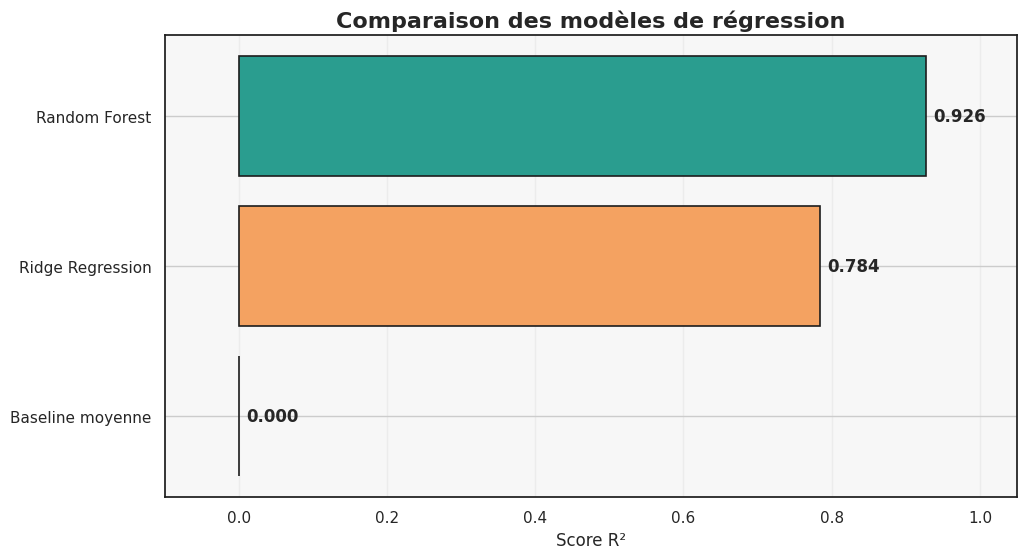

In [15]:
# ============================================================
# 10. Visualisation comparative des scores
# ============================================================

plt.figure(figsize=(11, 6))
plot_df = results_df.sort_values("R²")

bars = plt.barh(
    plot_df["Modèle"],
    plot_df["R²"],
    color=[INNO_GREY, INNO_YELLOW, INNO_GREEN],
    edgecolor=DARK,
    linewidth=1.2
)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, f"{width:.3f}", va="center", fontweight="bold")

plt.title("Comparaison des modèles de régression")
plt.xlabel("Score R²")
plt.xlim(min(0, plot_df["R²"].min() - 0.1), 1.05)
plt.grid(axis="x", alpha=0.25)
plt.show()

Ce graphique compare les performances des différents modèles de régression à partir du score R². La baseline moyenne obtient un score de 0, ce qui signifie qu’elle ne capture aucune relation exploitable dans les données et sert uniquement de référence minimale. La régression Ridge atteint un score de 0,784, ce qui montre qu’un modèle linéaire régularisé parvient déjà à expliquer une part importante de la variation du trafic. Cependant, le modèle Random Forest obtient le meilleur résultat avec un score R² de 0,926. Cette performance indique qu’il modélise beaucoup mieux les relations complexes et non linéaires entre les variables temporelles, météorologiques et le volume de trafic. Pour InnoMoov, ce modèle est donc le plus pertinent pour anticiper les périodes de congestion et alimenter un système d’aide à la décision pour la gestion intelligente de flotte.

## 9. Évaluation détaillée du modèle final

Les métriques utilisées sont :

- **R²** : part de la variance expliquée par le modèle ;
- **MAE** : erreur absolue moyenne en véhicules ;
- **RMSE** : erreur quadratique moyenne, plus sensible aux grosses erreurs.

Le modèle final est évalué sur des données futures qui n’ont pas été utilisées pendant l’entraînement.

In [16]:
# ============================================================
# 11. Évaluation finale du Random Forest
# ============================================================

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"R²   : {r2:.4f}")
print(f"MAE  : {mae:.2f} véhicules")
print(f"RMSE : {rmse:.2f} véhicules")

metrics_table = pd.DataFrame({
    "Métrique": ["R²", "MAE", "RMSE"],
    "Valeur": [r2, mae, rmse],
    "Interprétation": [
        "Part de la variabilité du trafic expliquée par le modèle",
        "Erreur moyenne en nombre de véhicules",
        "Erreur moyenne pénalisant fortement les gros écarts"
    ]
})

display(metrics_table)

R²   : 0.9265
MAE  : 300.73 véhicules
RMSE : 533.30 véhicules


,Métrique,Valeur,Interprétation
0,R²,0.926535,Part de la variabilité du trafic expliquée par...
1,MAE,300.732457,Erreur moyenne en nombre de véhicules
2,RMSE,533.304807,Erreur moyenne pénalisant fortement les gros é...


Le modèle Random Forest obtient un score R² de 0,9265, ce qui signifie qu’il explique environ 92,65 % de la variabilité du volume de trafic sur les données de test. Cette performance est très satisfaisante pour un problème de prédiction du trafic urbain, car le trafic dépend de nombreux facteurs non linéaires comme l’heure, le jour, la météo ou les périodes de pointe.

L’erreur absolue moyenne (MAE) est de 300,73 véhicules, ce qui indique qu’en moyenne, la prédiction du modèle s’écarte d’environ 301 véhicules du trafic réel. Le RMSE de 533,30 véhicules, plus sensible aux grosses erreurs, montre que certaines prédictions sont plus éloignées de la réalité, probablement lors des pics de congestion ou de situations particulières.

Pour InnoMoov, ces résultats montrent que le modèle est suffisamment performant pour servir d’outil d’aide à la décision : anticipation des zones de saturation, ajustement des itinéraires, meilleure disponibilité des flottes électriques et planification plus intelligente des périodes de recharge.

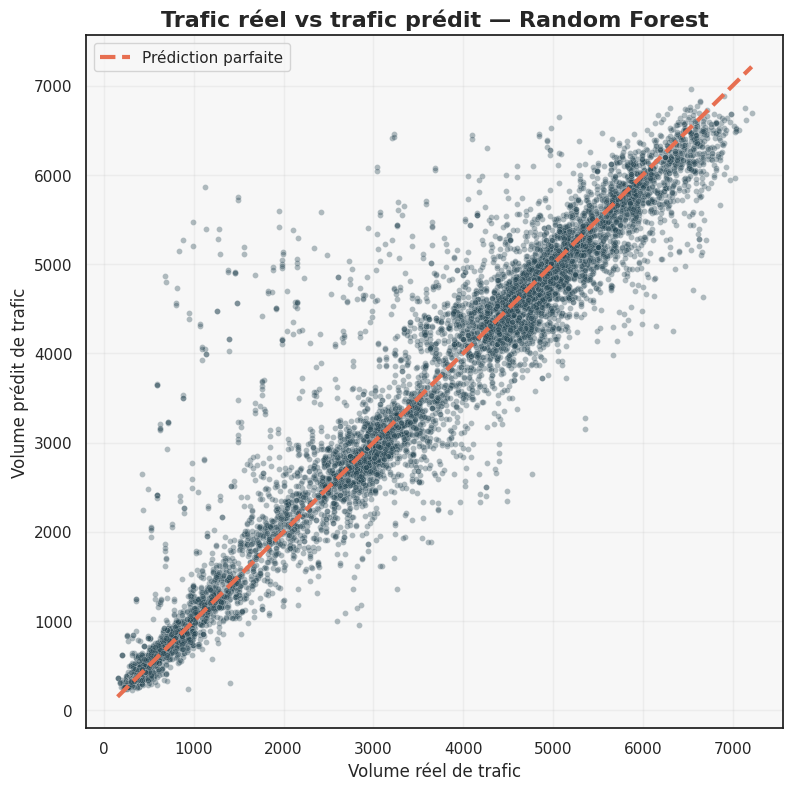

In [17]:
# ============================================================
# 12. Réel vs prédit
# ============================================================

plt.figure(figsize=(9, 9))
plt.scatter(
    y_test,
    y_pred,
    alpha=0.35,
    s=18,
    color=INNO_BLUE,
    edgecolor="white",
    linewidth=0.25
)

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color=INNO_ORANGE,
    linewidth=3,
    linestyle="--",
    label="Prédiction parfaite"
)

plt.title("Trafic réel vs trafic prédit — Random Forest")
plt.xlabel("Volume réel de trafic")
plt.ylabel("Volume prédit de trafic")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

Voici une confirmation de la bonne capacité du modèle à reproduire les variations du trafic. Le modèle parvient notamment à prédire correctement les faibles volumes de circulation ainsi que les niveaux de trafic élevés.

Quelques écarts restent visibles, surtout pour certains volumes intermédiaires et élevés. Ces erreurs peuvent s’expliquer par des situations plus complexes à anticiper, comme des événements exceptionnels, des conditions météo particulières ou des pics de congestion inhabituels.

Pour InnoMoov, ce résultat est encourageant : le modèle peut être utilisé pour anticiper le niveau de trafic et aider à ajuster les itinéraires, la disponibilité des véhicules et la planification opérationnelle de la flotte.

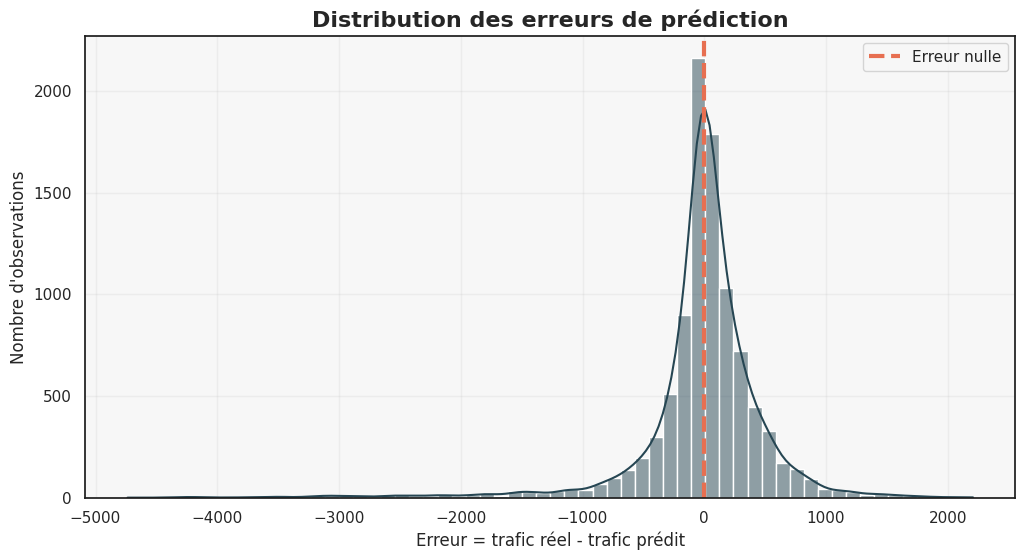

Erreur moyenne : -13.11
Erreur médiane : 11.44


In [18]:
# ============================================================
# 13. Analyse des erreurs
# ============================================================

errors = y_test - y_pred

plt.figure(figsize=(12, 6))
sns.histplot(
    errors,
    bins=60,
    kde=True,
    color=INNO_BLUE,
    edgecolor="white"
)
plt.axvline(0, color=INNO_ORANGE, linewidth=3, linestyle="--", label="Erreur nulle")
plt.title("Distribution des erreurs de prédiction")
plt.xlabel("Erreur = trafic réel - trafic prédit")
plt.ylabel("Nombre d'observations")
plt.legend()
plt.grid(alpha=0.25)
plt.show()

print(f"Erreur moyenne : {errors.mean():.2f}")
print(f"Erreur médiane : {np.median(errors):.2f}")

Ce graphique présente la distribution des erreurs de prédiction du modèle Random Forest, calculées comme la différence entre le trafic réel et le trafic prédit. La ligne verticale pointillée représente l’erreur nulle, c’est-à-dire une prédiction parfaitement exacte.

On observe que la majorité des erreurs sont fortement concentrées autour de zéro, ce qui confirme que le modèle réalise globalement des prédictions précises. L’erreur moyenne est de -13,11 véhicules, une valeur très proche de zéro : cela indique que le modèle ne présente pas de biais global important. Autrement dit, il ne surestime ni ne sous-estime fortement le trafic en moyenne.

L’erreur médiane est de 11,44 véhicules, également très proche de zéro, ce qui montre que la moitié des prédictions ont une erreur faible et que le modèle reste stable sur une grande partie des observations.

On remarque toutefois une queue plus étendue du côté des erreurs négatives. Cela signifie que, dans certains cas particuliers, le modèle a tendance à prédire un trafic supérieur au trafic réellement observé. Ces écarts peuvent correspondre à des situations atypiques : baisse soudaine du trafic, conditions météo particulières, événement local, jour férié ou rupture de tendance.

Pour InnoMoov, cette analyse est importante car elle montre que le modèle est fiable dans la majorité des cas, tout en mettant en évidence les situations où une vigilance opérationnelle reste nécessaire. Dans un usage industriel, ces erreurs extrêmes pourraient être surveillées dans un dashboard afin d’identifier les contextes où le modèle doit être recalibré ou enrichi avec de nouvelles données temps réel.

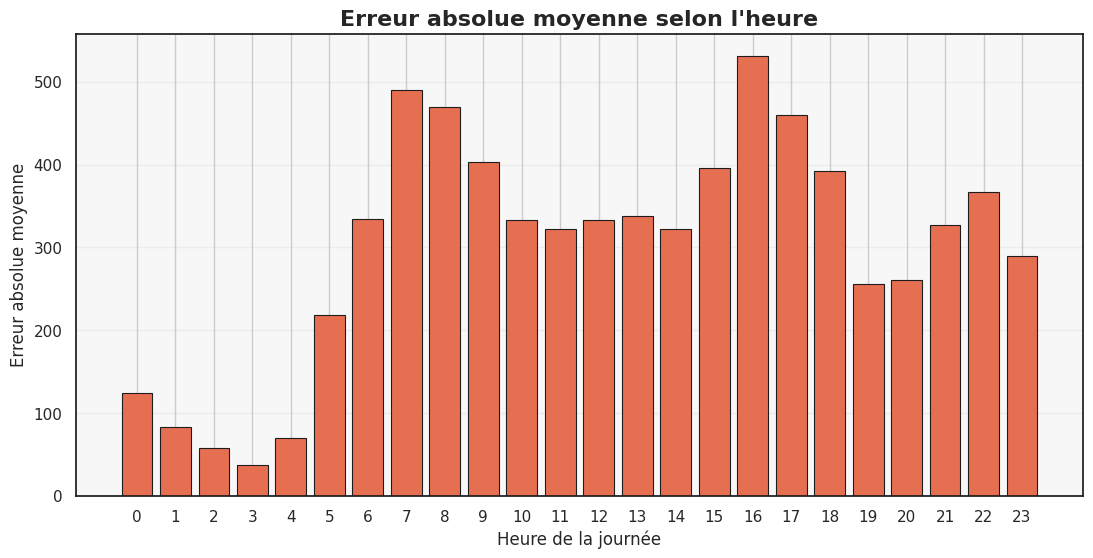

In [19]:
# ============================================================
# 14. Résidus selon l'heure : où le modèle se trompe-t-il ?
# ============================================================

residuals_df = X_test.copy()
residuals_df["y_true"] = y_test.values
residuals_df["y_pred"] = y_pred
residuals_df["error"] = residuals_df["y_true"] - residuals_df["y_pred"]
residuals_df["abs_error"] = residuals_df["error"].abs()

error_by_hour = residuals_df.groupby("hour", as_index=False)["abs_error"].mean()

plt.figure(figsize=(13, 6))
plt.bar(
    error_by_hour["hour"],
    error_by_hour["abs_error"],
    color=INNO_ORANGE,
    edgecolor=DARK,
    linewidth=0.8
)
plt.title("Erreur absolue moyenne selon l'heure")
plt.xlabel("Heure de la journée")
plt.ylabel("Erreur absolue moyenne")
plt.xticks(range(0, 24))
plt.grid(axis="y", alpha=0.25)
plt.show()

Ce graphique montre que les erreurs du modèle varient selon l’heure de la journée. Les prédictions sont très précises la nuit, lorsque le trafic est faible et plus stable. En revanche, les erreurs augmentent fortement aux heures de pointe, notamment entre 7h-9h et 16h-18h.

Cela indique que le trafic est plus difficile à prévoir pendant les périodes de forte activité. Pour InnoMoov, ces créneaux doivent donc être surveillés en priorité dans le dashboard de pilotage.

## 10. Interprétation du modèle

Le modèle Random Forest est performant, mais il faut aussi comprendre les facteurs qui influencent ses prédictions.

Pour cela, on utilise deux approches :

1. **Importance native Random Forest** : rapide, mais parfois biaisée ;
2. **Permutation importance** : plus robuste, car elle mesure la perte de performance lorsqu’une variable est perturbée.

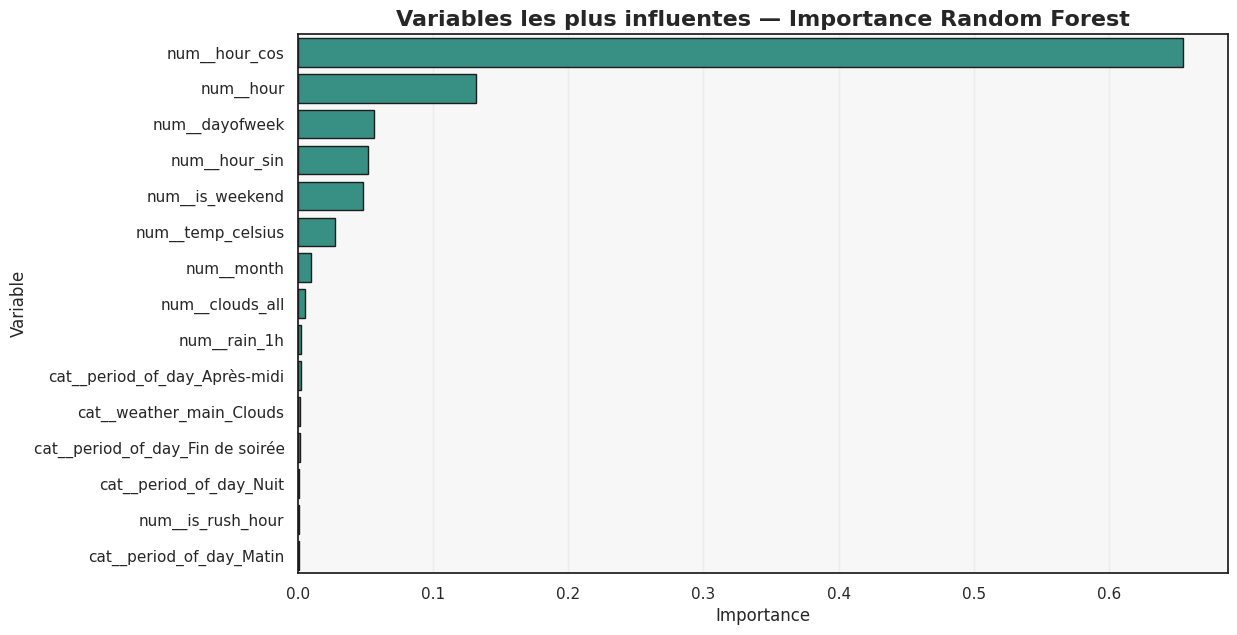

,feature,importance
6,num__hour_cos,0.654925
4,num__hour,0.131727
7,num__dayofweek,0.056693
5,num__hour_sin,0.051849
9,num__is_weekend,0.048132
0,num__temp_celsius,0.027238
8,num__month,0.009580
3,num__clouds_all,0.005527
1,num__rain_1h,0.002583
34,cat__period_of_day_Après-midi,0.002253


In [20]:
# ============================================================
# 15. Importance native des variables transformées
# ============================================================

rf_model = model.named_steps["regressor"]
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

importances = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
}).sort_values(by="importance", ascending=False)

top_importances = importances.head(15)

plt.figure(figsize=(12, 7))
sns.barplot(
    data=top_importances,
    x="importance",
    y="feature",
    color=INNO_GREEN,
    edgecolor=DARK
)
plt.title("Variables les plus influentes — Importance Random Forest")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.grid(axis="x", alpha=0.25)
plt.show()

display(top_importances)

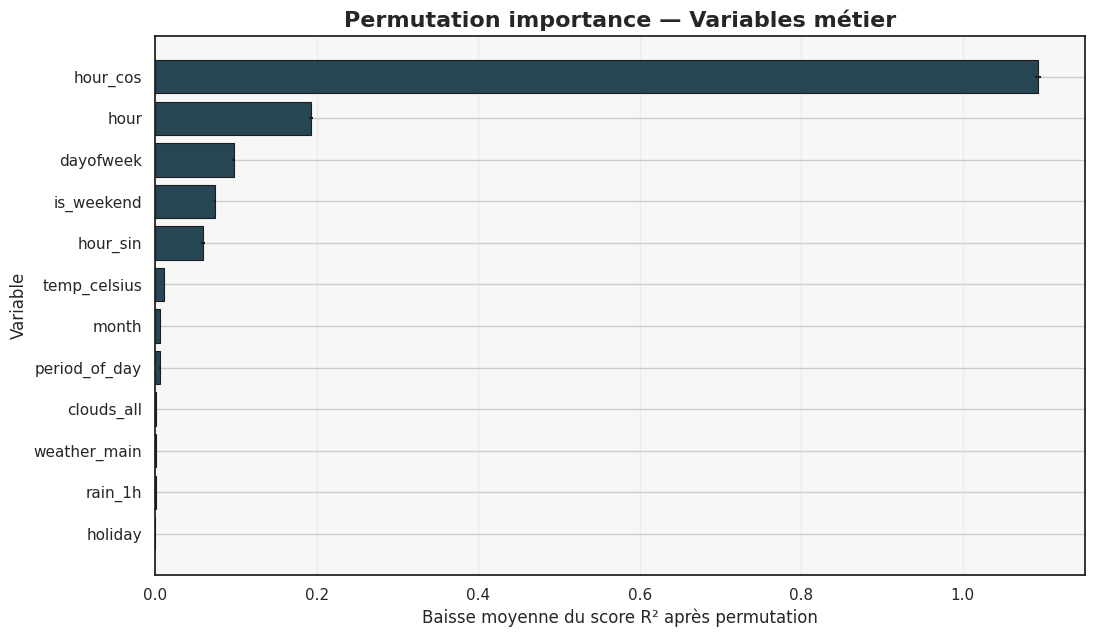

,feature,importance_mean,importance_std
8,hour_cos,1.093074,0.003870
6,hour,0.192594,0.002908
9,dayofweek,0.096988,0.001823
11,is_weekend,0.073634,0.001611
7,hour_sin,0.058928,0.002265
1,temp_celsius,0.010951,0.000623
10,month,0.006296,0.000850
13,period_of_day,0.005328,0.000312
4,clouds_all,0.001229,0.000282
5,weather_main,0.000486,0.000172


In [21]:
# ============================================================
# 16. Permutation importance sur les variables d'entrée
# ============================================================

perm = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    scoring="r2"
)

perm_importances = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

top_perm = perm_importances.head(12)

plt.figure(figsize=(12, 7))
plt.barh(
    top_perm["feature"][::-1],
    top_perm["importance_mean"][::-1],
    xerr=top_perm["importance_std"][::-1],
    color=INNO_BLUE,
    edgecolor=DARK,
    linewidth=0.8
)
plt.title("Permutation importance — Variables métier")
plt.xlabel("Baisse moyenne du score R² après permutation")
plt.ylabel("Variable")
plt.grid(axis="x", alpha=0.25)
plt.show()

display(top_perm)

Les deux graphiques confirment que les variables temporelles sont les plus déterminantes dans la prédiction du trafic. La variable liée à l’heure, notamment hour_cos, domine largement, ce qui montre que le trafic suit fortement un cycle journalier.

Les variables hour, dayofweek et is_weekend jouent aussi un rôle important : le modèle distingue bien les jours ouvrés, les week-ends et les périodes de forte activité.

En revanche, les variables météo comme la température, la pluie ou les nuages ont un impact plus faible dans ce modèle. Pour InnoMoov, cela signifie que la planification de flotte doit surtout s’appuyer sur les rythmes horaires et hebdomadaires du trafic, tout en gardant la météo comme facteur secondaire.

## 11. Utilisation du modèle dans le process industriel InnoMoov

Le modèle peut être intégré dans une chaîne Industrie 4.0 :

```text
Capteurs IoT / données trafic / météo / calendrier
        ↓
Collecte et centralisation des données
        ↓
Préparation et enrichissement des variables
        ↓
Modèle de régression supervisée
        ↓
Prédiction du volume de trafic
        ↓
Décisions InnoMoov : flotte, itinéraires, recharge, supervision, alertes
```

L’intérêt industriel est concret :

- anticiper les congestions ;
- repositionner les véhicules avant les pics ;
- optimiser les itinéraires ;
- planifier la recharge hors heures de saturation ;
- réduire les kilomètres inutiles ;
- améliorer la qualité de service ;
- diminuer la consommation énergétique et les émissions de CO₂.

In [22]:
# ============================================================
# 17. Scénarios industriels InnoMoov
# ============================================================

scenarios = pd.DataFrame([
    {
        "scenario": "Lundi 8h — pic du matin, temps clair",
        "holiday": "None",
        "temp_celsius": 18,
        "rain_1h": 0,
        "snow_1h": 0,
        "clouds_all": 20,
        "weather_main": "Clear",
        "hour": 8,
        "dayofweek": 0,
        "month": 5,
        "is_weekend": 0,
        "is_rush_hour": 1,
        "period_of_day": "Matin"
    },
    {
        "scenario": "Vendredi 18h — pic du soir, pluie",
        "holiday": "None",
        "temp_celsius": 12,
        "rain_1h": 3,
        "snow_1h": 0,
        "clouds_all": 90,
        "weather_main": "Rain",
        "hour": 18,
        "dayofweek": 4,
        "month": 11,
        "is_weekend": 0,
        "is_rush_hour": 1,
        "period_of_day": "Soir"
    },
    {
        "scenario": "Dimanche 14h — week-end, temps clair",
        "holiday": "None",
        "temp_celsius": 22,
        "rain_1h": 0,
        "snow_1h": 0,
        "clouds_all": 10,
        "weather_main": "Clear",
        "hour": 14,
        "dayofweek": 6,
        "month": 7,
        "is_weekend": 1,
        "is_rush_hour": 0,
        "period_of_day": "Après-midi"
    },
    {
        "scenario": "Mardi 23h — trafic nocturne",
        "holiday": "None",
        "temp_celsius": 8,
        "rain_1h": 0,
        "snow_1h": 0,
        "clouds_all": 40,
        "weather_main": "Clouds",
        "hour": 23,
        "dayofweek": 1,
        "month": 2,
        "is_weekend": 0,
        "is_rush_hour": 0,
        "period_of_day": "Fin de soirée"
    }
])

# Ajout des variables cycliques nécessaires
scenarios["hour_sin"] = np.sin(2 * np.pi * scenarios["hour"] / 24)
scenarios["hour_cos"] = np.cos(2 * np.pi * scenarios["hour"] / 24)

scenario_features = scenarios[features]
scenarios["traffic_volume_predicted"] = model.predict(scenario_features).round(0).astype(int)


def recommendation(volume):
    if volume >= 5000:
        return "Trafic critique : renforcer la flotte, proposer des itinéraires alternatifs, éviter les recharges en pic."
    if volume >= 3500:
        return "Trafic élevé : surveiller les zones sensibles et ajuster les itinéraires."
    if volume >= 2000:
        return "Trafic modéré : fonctionnement normal avec supervision."
    return "Trafic faible : période favorable à la recharge et à la maintenance légère."

scenarios["decision_innomoov"] = scenarios["traffic_volume_predicted"].apply(recommendation)

display(scenarios[["scenario", "traffic_volume_predicted", "decision_innomoov"]])

,scenario,traffic_volume_predicted,decision_innomoov
0,"Lundi 8h — pic du matin, temps clair",5707,"Trafic critique : renforcer la flotte, propose..."
1,"Vendredi 18h — pic du soir, pluie",4011,Trafic élevé : surveiller les zones sensibles ...
2,"Dimanche 14h — week-end, temps clair",4488,Trafic élevé : surveiller les zones sensibles ...
3,Mardi 23h — trafic nocturne,1192,Trafic faible : période favorable à la recharg...


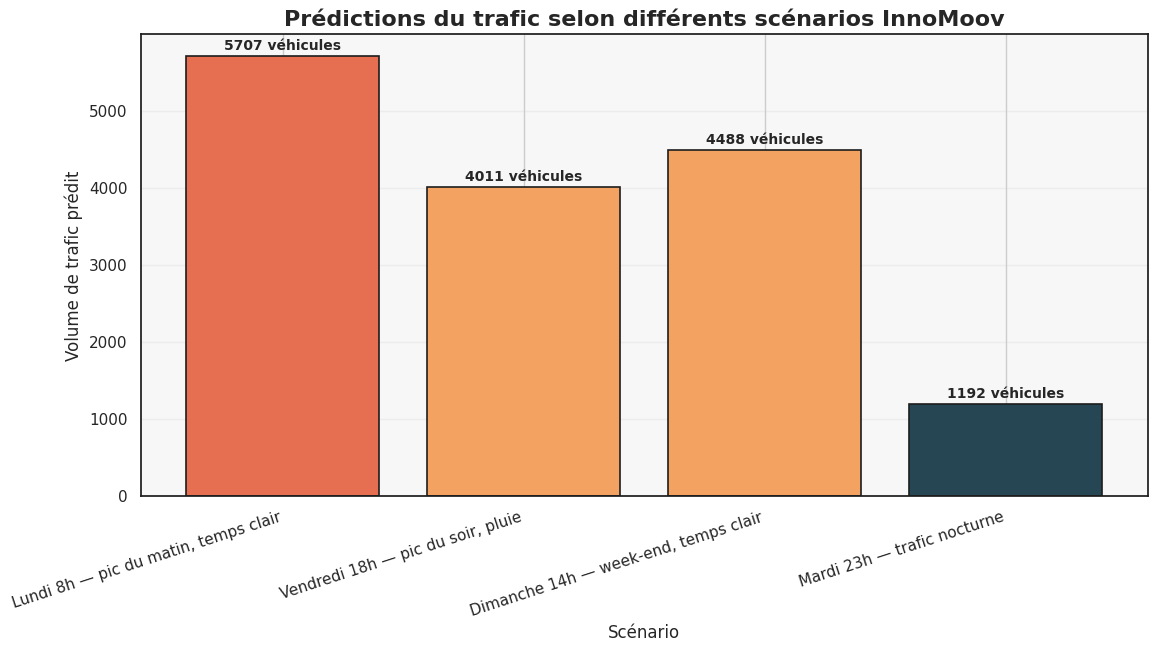

In [23]:
# ============================================================
# 18. Visualisation des scénarios prédits
# ============================================================

plt.figure(figsize=(13, 6))
colors = [INNO_ORANGE if v >= 5000 else INNO_YELLOW if v >= 3500 else INNO_GREEN if v >= 2000 else INNO_BLUE for v in scenarios["traffic_volume_predicted"]]

bars = plt.bar(
    scenarios["scenario"],
    scenarios["traffic_volume_predicted"],
    color=colors,
    edgecolor=DARK,
    linewidth=1.2
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 80,
        f"{int(height)} véhicules",
        ha="center",
        fontsize=10,
        fontweight="bold"
    )

plt.title("Prédictions du trafic selon différents scénarios InnoMoov")
plt.ylabel("Volume de trafic prédit")
plt.xlabel("Scénario")
plt.xticks(rotation=18, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.show()

## 12. Formulaire de test interactif

Cette cellule permet de tester le modèle avec des valeurs personnalisées.

Si `ipywidgets` est disponible dans l’environnement, un formulaire interactif est affiché. Sinon, le notebook reste exploitable avec la fonction `predict_traffic()`.

In [24]:
# ============================================================
# 19. Fonction de prédiction réutilisable
# ============================================================

def predict_traffic(
    hour=8,
    dayofweek=0,
    month=5,
    temp_celsius=18,
    rain_1h=0,
    snow_1h=0,
    clouds_all=20,
    weather_main="Clear",
    holiday="None"
):
    """Prédit le trafic et retourne une recommandation opérationnelle InnoMoov."""
    is_weekend = int(dayofweek in [5, 6])
    is_rush_hour = int(hour in [7, 8, 9, 16, 17, 18])

    if hour <= 5:
        period_of_day = "Nuit"
    elif hour <= 11:
        period_of_day = "Matin"
    elif hour <= 16:
        period_of_day = "Après-midi"
    elif hour <= 20:
        period_of_day = "Soir"
    else:
        period_of_day = "Fin de soirée"

    input_df = pd.DataFrame([{
        "holiday": holiday,
        "temp_celsius": temp_celsius,
        "rain_1h": rain_1h,
        "snow_1h": snow_1h,
        "clouds_all": clouds_all,
        "weather_main": weather_main,
        "hour": hour,
        "hour_sin": np.sin(2 * np.pi * hour / 24),
        "hour_cos": np.cos(2 * np.pi * hour / 24),
        "dayofweek": dayofweek,
        "month": month,
        "is_weekend": is_weekend,
        "is_rush_hour": is_rush_hour,
        "period_of_day": period_of_day
    }])

    volume = int(round(model.predict(input_df[features])[0], 0))
    return volume, recommendation(volume)

# Exemple d'utilisation directe
volume, reco = predict_traffic(hour=8, dayofweek=0, month=5, temp_celsius=18, weather_main="Clear")
print(f"Volume de trafic prédit : {volume} véhicules")
print("Recommandation InnoMoov :", reco)

Volume de trafic prédit : 5707 véhicules
Recommandation InnoMoov : Trafic critique : renforcer la flotte, proposer des itinéraires alternatifs, éviter les recharges en pic.


In [28]:
# ============================================================
# 20. Formulaire interactif, si ipywidgets est disponible
# ============================================================

try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    hour_w = widgets.IntSlider(value=8, min=0, max=23, step=1, description="Heure")
    day_w = widgets.Dropdown(
        options=[("Lundi", 0), ("Mardi", 1), ("Mercredi", 2), ("Jeudi", 3), ("Vendredi", 4), ("Samedi", 5), ("Dimanche", 6)],
        value=0,
        description="Jour"
    )
    month_w = widgets.IntSlider(value=5, min=1, max=12, step=1, description="Mois")
    temp_w = widgets.FloatSlider(value=18, min=-20, max=45, step=0.5, description="Temp. °C")
    rain_w = widgets.FloatSlider(value=0, min=0, max=20, step=0.1, description="Pluie")
    snow_w = widgets.FloatSlider(value=0, min=0, max=10, step=0.1, description="Neige")
    clouds_w = widgets.IntSlider(value=20, min=0, max=100, step=5, description="Nuages %")
    weather_w = widgets.Dropdown(
        options=sorted(df_clean["weather_main"].dropna().unique().tolist()),
        value="Clear" if "Clear" in df_clean["weather_main"].unique() else sorted(df_clean["weather_main"].dropna().unique().tolist())[0],
        description="Météo"
    )
    holiday_w = widgets.Dropdown(
        options=sorted(df_clean["holiday"].dropna().unique().tolist()),
        value="None" if "None" in df_clean["holiday"].unique() else sorted(df_clean["holiday"].dropna().unique().tolist())[0],
        description="Férié"
    )

    button = widgets.Button(description="Prédire", button_style="success")
    output = widgets.Output()

    def on_click(_):
        with output:
            clear_output()
            volume, reco = predict_traffic(
                hour=hour_w.value,
                dayofweek=day_w.value,
                month=month_w.value,
                temp_celsius=temp_w.value,
                rain_1h=rain_w.value,
                snow_1h=snow_w.value,
                clouds_all=clouds_w.value,
                weather_main=weather_w.value,
                holiday=holiday_w.value
            )
            display(Markdown(f"### Volume de trafic prédit : **{volume} véhicules**"))
            display(Markdown(f"**Recommandation InnoMoov :** {reco}"))

    button.on_click(on_click)

    display(widgets.VBox([
        widgets.HBox([hour_w, day_w, month_w]),
        widgets.HBox([temp_w, rain_w, snow_w]),
        widgets.HBox([clouds_w, weather_w, holiday_w]),
        button,
        output
    ]))

except Exception as e:
    print("ipywidgets n'est pas disponible dans cet environnement.")
    print("Utilisez directement la fonction predict_traffic().")
    print("Détail :", e)

## 13. Limites et perspectives

Le modèle constitue une première brique solide pour une solution InnoMoov, mais plusieurs limites doivent être prises en compte :

- le dataset ne contient pas tous les événements urbains possibles : accidents, travaux, manifestations, événements sportifs ;
- la météo est prise en compte, mais sans données très fines de localisation ;
- la prédiction est basée sur des données historiques, pas encore sur un flux temps réel ;
- le modèle doit être surveillé dans le temps pour éviter la dérive de performance.

### Améliorations futures

- intégrer des données IoT temps réel issues de capteurs urbains ;
- connecter le modèle à un dashboard de supervision InnoMoov ;
- ajouter des données de flotte : disponibilité des véhicules, état batterie, localisation ;
- tester des modèles plus avancés : Gradient Boosting, XGBoost, LightGBM, modèles temporels ;
- mettre en place un suivi MLOps : monitoring, réentraînement, alertes de dérive.

## 14. Conclusion

Ce TP a permis de construire un modèle de régression supervisée appliqué à un besoin industriel concret : la **prédiction du trafic urbain pour InnoMoov**.

La démarche suivie est complète :

- identification du besoin métier ;
- choix d’un dataset cohérent ;
- analyse exploratoire ;
- enrichissement des variables ;
- choix du modèle via la carte Scikit-Learn ;
- comparaison avec une baseline et une Ridge Regression ;
- entraînement d’un Random Forest Regressor ;
- évaluation avec R², MAE et RMSE ;
- visualisation des erreurs et des variables importantes ;
- exploitation sur des scénarios industriels.

Pour InnoMoov, ce modèle peut devenir un outil d’aide à la décision permettant d’anticiper les congestions, d’optimiser les flottes électriques, de réduire les retards, d’améliorer la qualité de service et de limiter l’impact énergétique.

La donnée devient ainsi un levier opérationnel majeur pour une mobilité plus intelligente, plus fluide et plus durable.